# Implement PCA and Explore Corpus (REWRITE HEADER?)

Notes:

I am following along with my M07 02 PCA with SKL Notes and my M07 HW as I complete this section.

## Setup

### Import Libraries

In [55]:
# import libraries # DO I NEED ALL OF THESE?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD

In [56]:
# import plotly_express as px
# import plotly.io as pio
# pio.renderers.default = 'iframe'

### Configuration

In [57]:
# # specify OHCO and bags # DO I ONLY NEED OHCO HERE?
# OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']

# bags = dict(
#     SENTS = OHCO[:4],
#     PARAS = OHCO[:3],
#     CHAPS = OHCO[:2],
#     BOOKS = OHCO[:1]
# )

In [58]:
# set chapter as bag # DO I NEED THIS?
# bag = "CHAPS"

### Load Data

In [59]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
# TFIDF = pd.read_csv('data/TFIDF.csv', sep='\t').set_index('book_id')
TFIDF_L2 = pd.read_csv('data/TFIDF_L2.csv', sep='\t').set_index(['book_id', 'chap_num']) # recall this is TFIDF_reduced L2 normalized

## Run PCA

Pass the TFIDF table with reduced feature space SKLearn's PCA class.

### Instantiate PCA Engine

I will start with default values for the constructor, and will set random_state to 36 and the number of components to 20. Then I will plot the cumulative explained variance, and then refit with my chosen number of components where the curve begins to flatten out.

/tmp/ipykernel_515690/4086206609.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


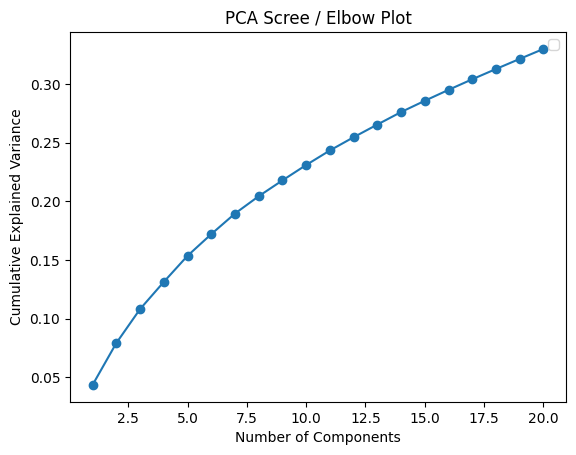

In [60]:
# instantiate PCA engine with defaults except random_state=36 and n_components=20
pca_explore = PCA(n_components=20, random_state=36)
pca_explore.fit(TFIDF_L2)

cumvar = np.cumsum(pca_explore.explained_variance_ratio_)

plt.plot(range(1, len(cumvar)+1), cumvar, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree / Elbow Plot')
plt.legend()
plt.show()

This scree plot doesn't have a pronounced elbow. Variance is accumulating slowly across components. I am choosing ten components as a practical limit to balance variance coverage and interpretability. 

In [61]:
# reinstantiate PCA engine with defaults except random_state=36 and n_components=10
pca_engine = PCA(n_components = 10, random_state = 36)

### Build PCA Document-Component Matrix (DCM)

Fit and transform the normalized, reduced TFIDF data (TFIDF_L2) to create the document component matrix.

In [62]:
# fit and transform the normalized reduced TFIDF data (pass it to PCA engine) to create document component matrix
DCM = pd.DataFrame(
    pca_engine.fit_transform(TFIDF_L2),
    index = TFIDF_L2.index # pca engine returns a numpy matrix which we turn back into a dataframe
)

DCM.columns = [f'PC{i}' for i in range(DCM.shape[1])]

DCM # now we have a document component matrix

PC0       PC1       PC2       PC3  \
book_id                      chap_num                                           
giants-bread                 0         0.036466 -0.084828 -0.084147  0.005797   
                             1         0.082022 -0.107696 -0.261797  0.012602   
                             2         0.099711 -0.115417 -0.278889  0.057608   
                             3         0.078195 -0.138639 -0.236045  0.043606   
                             4         0.093759 -0.210806 -0.300206  0.042657   
...                                         ...       ...       ...       ...   
the-seven-dials-mystery      31        0.505613  0.333729  0.053380 -0.472361   
                             32        0.163720  0.065719 -0.049730 -0.167721   
                             33        0.223877  0.053026  0.040991 -0.209141   
                             34        0.329597  0.171641  0.022188  0.389888   
the-tragedy-at-marsdon-manor 1        -0.216950  0.059797  0.062543 -0.005739   

                                            PC4       PC5       PC6       PC7  \
book_id                      chap_num                                           
giants-bread                 0        -0.031220  0.060298 -0.003879  0.012188   
                             1         0.000047 -0.061190  0.111764  0.052364   
                             2         0.072935 -0.150160  0.161276 -0.023310   
                             3        -0.009671 -0.086539  0.079066  0.074018   
                             4         0.007968 -0.161418  0.161345  0.016311   
...                                         ...       ...       ...       ...   
the-seven-dials-mystery      31       -0.050112 -0.026877  0.130800  0.058819   
                             32       -0.003956  0.033912 -0.004323 -0.164992   
                             33       -0.097167  0.008489 -0.016599 -0.027511   
                             34        0.125197 -0.033651  0.122072 -0.151036   
the-tragedy-at-marsdon-manor 1        -0.174519  0.003143  0.089462 -0.027379   

                                            PC8       PC9  
book_id                      chap_num                      
giants-bread                 0        -0.047312 -0.009349  
                             1        -0.058652 -0.031529  
                             2         0.035129 -0.251264  
                             3        -0.027152 -0.089393  
                             4        -0.037586 -0.155406  
...                                         ...       ...  
the-seven-dials-mystery      31        0.043674 -0.154647  
                             32       -0.043443  0.106867  
                             33        0.056321  0.008675  
                             34       -0.018824 -0.191853  
the-tragedy-at-marsdon-manor 1         0.009239  0.062193  

[325 rows x 10 columns]

### Build PCA Loadings (Component-Term Matrix)

Create a data frame LOADINGS that contains terms as observations and components as features.

Here is the formula from our M07 HW: `pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_)`

In [63]:
# create LOADINGS dataframe with terms as observations and components as features

LOADINGS = pd.DataFrame(
    pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_),
    index = TFIDF_L2.columns,
    # use PC column names from DCM
    columns = DCM.columns
)

# confirm index name is 'term_str' (don't actually need bc this came through via BOW initially?)
LOADINGS.index.name = 'term_str'

LOADINGS

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
able,-0.001867,-0.002694,-0.001557,0.000610,-0.004450,-0.000331,-0.000222,0.000570,-0.000129,0.000608
above,0.001145,-0.000525,-0.000806,0.000019,-0.001964,0.000643,-0.001806,-0.000121,0.000430,0.000922
abruptly,0.001186,-0.000009,-0.001144,-0.000591,0.000184,0.000759,-0.002341,0.000739,-0.001335,-0.000922
absolutely,0.000473,-0.002035,0.000640,0.000309,-0.000127,0.000996,0.002255,-0.001434,0.000691,0.001434
absurd,-0.001260,-0.002423,-0.000692,-0.000330,0.000948,0.001459,0.000919,-0.000051,-0.000583,0.000341
...,...,...,...,...,...,...,...,...,...,...
yesterday,-0.001345,-0.001221,0.005336,0.002488,0.003591,0.000654,-0.000019,-0.001488,0.000506,0.001702
yet,-0.000996,-0.001851,-0.002789,-0.000505,-0.001605,-0.002045,0.001397,0.000323,0.000308,0.001712
young,0.002618,-0.003406,-0.001356,-0.000576,-0.003697,0.002034,-0.006658,-0.009199,0.004171,0.001765


### Create a DOC data frame for Visualization

I will now create a DOC table from the DCM index in which each row represents a bag (in this case chapter).

It will have ['book_id', 'chap_num'] as its index.

This table will have information from the LIB table joined to it, so that each chapter is identified with an author, title, and genre. (ADD OTHER FEATURES?)

Finally, I will add a DOC feature label that is a string which concatenates title and chapter.

These data will appear in my visualizations.

In [65]:
# create initial DOC table with DCM index
DOC = pd.DataFrame(index=DCM.index)

# join metadata from LIB (join on book_id)
DOC = DOC.join(LIB[['title', 'sleuth', 'pub_year_original', 'work_type']], on='book_id')

# create label column
book_str = DOC.index.get_level_values('book_id')
chap_str = DOC.index.get_level_values('chap_num').astype(str)

DOC['label'] = book_str + ' ch.' + chap_str

DOC

title  \
book_id                      chap_num                                 
giants-bread                 0                        Giant’s Bread   
                             1                        Giant’s Bread   
                             2                        Giant’s Bread   
                             3                        Giant’s Bread   
                             4                        Giant’s Bread   
...                                                             ...   
the-seven-dials-mystery      31             The Seven Dials Mystery   
                             32             The Seven Dials Mystery   
                             33             The Seven Dials Mystery   
                             34             The Seven Dials Mystery   
the-tragedy-at-marsdon-manor 1         The Tragedy at Marsdon Manor   

                                                      sleuth  \
book_id                      chap_num                          
giants-bread                 0                           NaN   
                             1                           NaN   
                             2                           NaN   
                             3                           NaN   
                             4                           NaN   
...                                                      ...   
the-seven-dials-mystery      31        Superintendent Battle   
                             32        Superintendent Battle   
                             33        Superintendent Battle   
                             34        Superintendent Battle   
the-tragedy-at-marsdon-manor 1                Hercule Poirot   

                                       pub_year_original    work_type  \
book_id                      chap_num                                   
giants-bread                 0                      1930        novel   
                             1                      1930        novel   
                             2                      1930        novel   
                             3                      1930        novel   
                             4                      1930        novel   
...                                                  ...          ...   
the-seven-dials-mystery      31                     1929        novel   
                             32                     1929        novel   
                             33                     1929        novel   
                             34                     1929        novel   
the-tragedy-at-marsdon-manor 1                      1923  short_story   

                                                                   label  
book_id                      chap_num                                     
giants-bread                 0                         giants-bread ch.0  
                             1                         giants-bread ch.1  
                             2                         giants-bread ch.2  
                             3                         giants-bread ch.3  
                             4                         giants-bread ch.4  
...                                                                  ...  
the-seven-dials-mystery      31            the-seven-dials-mystery ch.31  
                             32            the-seven-dials-mystery ch.32  
                             33            the-seven-dials-mystery ch.33  
                             34            the-seven-dials-mystery ch.34  
the-tragedy-at-marsdon-manor 1         the-tragedy-at-marsdon-manor ch.1  

[325 rows x 5 columns]

## Visualize

### PCA Visualization 1

TODO: 

Include a scatterplot of documents in the space created by the first two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

(INSERT IMAGE HERE)

(INSERT IMAGE HERE)

Briefly describe the nature of the polarity you see in the first component:

(INSERT DESCRIPTION HERE)

In [ ]:
# create a scatterplot of documents in the space created by the first 2 components
# coloring the points by sleuth

### PCA Visualization 2

## Save Outputs

In [64]:
# # save the updated VOCAB table to csv (replace the existing one created by 03-VOCAB.ipynb)
# VOCAB.to_csv('data/VOCAB.csv', sep='\t', index=True)

# # save the BOW table to csv
# BOW_chaps.to_csv('data/BOW_chaps.csv', sep='\t', index=True)

# # save the DTM table to csv
# DTM.to_csv('data/DTM.csv', sep='\t', index=True)

# # save the TFIDF table to csv
# TFIDF.to_csv('data/TFIDF.csv', sep='\t', index=True)

# # save the TFIDF_L2 table to csv
# TFIDF_L2.to_csv('data/TFIDF_L2.csv', sep='\t', index=True)